**[🏠 Course Home](00_START_HERE.ipynb) | ⏭️ Next: [Sheet 2: Beyond Conjugacy — Frequentist vs. Grid Approx](02_frequentist_vs_grid_approximation.ipynb)**

---

# Sheet 1: Foundations — The Beta Distribution & Exact Conjugate Updating
### *From First-Principles Proofs to Online Streaming Bayesian CI Flakiness Tracking*

Welcome to Sheet 1! We begin our journey into Bayesian modeling with the most intuitive, algebraically exact model in statistics: the **Beta-Binomial conjugate model** for probabilities, proportions, and rates strictly confined to the interval $[0, 1]$ (such as CI/CD test flakiness, user conversion rates, or network packet loss).

Here, you will learn the foundational math of Bayesian inference (Euler integral, Bayes' rule on Bernoulli trials, De Finetti exchangeability, Dutch book coherence, and Laplace's 1774 Rule of Succession) and build an online streaming test reliability tracker.

---

### Table of Contents
1. **Part 1: The Engineering Problem — CI/CD Test Flakiness**
2. **Part 2: The Beta Distribution from First Principles (Mathematics & Shapes)**
3. **Part 3: Foundational Proofs — Why Does the Beta Distribution Tell the Truth?**
4. **Part 4: The Algebraic Miracle of Beta-Binomial Conjugacy**
5. **Part 5: Interactive Streaming Updates Across CI Build Batches**
6. **Part 6: Automated CI Quarantine Decision Rules (Tail Risk)**
7. **Part 7: Decision Analysis — Bayesian A/B Testing & Relative Uplift**
8. **Part 8: Introduction to Fading Memory & Exponential Decay**
9. **Part 9: Hands-On Challenge Exercises**


## Part 1: The Problem of Test Flakiness

A **flaky test** is an automated test that exhibits non-deterministic outcomes (passing and failing intermittently on the identical code commit without any changes).

### Why Classical Frequentist Metrics Fail in CI/CD
1. **Small-Sample Illusion**: If a newly added test runs 3 times and passes 3 times, frequentist sample mean says $\hat{\theta} = 0\%$. But the true flakiness could easily be $10\%$.
2. **The Zero-Failure Trap**: When a test has 0 failures in 50 runs, classical MLE asserts standard error is 0. But absence of evidence is not evidence of zero risk!
3. **Batch vs. Continuous Reality**: CI/CD runs continuously in micro-batches (5 runs here, 20 runs there). We need a model that updates in real-time as builds finish without recomputing entire databases.

> [!NOTE]
> **Refresher: How Classical Maximum Likelihood Estimation (MLE) is Computed**
> For $n$ independent binary trials with $k$ observed events (e.g., test failures), the classical **Maximum Likelihood Estimate (MLE)** chooses the parameter value $\hat{\theta}$ that maximizes the data likelihood $\mathcal{L}(\theta) = \binom{n}{k} \theta^k (1 - \theta)^{n - k}$. Setting the log-likelihood derivative $\frac{d \log \mathcal{L}}{d\theta} = 0$ yields the intuitive empirical sample proportion:
> $$\hat{\theta}_{\text{MLE}} = \frac{k}{n} = \frac{\text{observed failures}}{\text{total runs}}$$
> When $k = 0$ (zero failures observed), $\hat{\theta}_{\text{MLE}} = \frac{0}{n} = 0\%$, which leads to the dangerous **Zero-Failure Fallacy** in safety-critical systems.

Bayesian inference solves this by maintaining a continuous probability distribution over the unknown flakiness parameter $\theta \in [0, 1]$.

## Part 2: Deep Dive into the Beta Distribution

A continuous random variable $\theta \in [0, 1]$ follows a Beta distribution $\theta \sim \text{Beta}(\alpha, \beta)$ if its probability density function (PDF) is:

$$f(\theta; \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \, \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$$

### Key Formulas & Hyperparameters as Pseudo-Counts
- **The Normalizing Constant**: $\text{B}(\alpha, \beta) = \int_0^1 \theta^{\alpha - 1} (1 - \theta)^{\beta - 1} d\theta = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$.
- **Pseudo-Counts Intuition**: In standard statistics, $\alpha - 1$ represents prior **"successes"** and $\beta - 1$ represents prior **"failures"**. In our CI/CD context (where $\theta$ is the test failure rate), $\alpha - 1$ represents prior **test failures** and $\beta - 1$ represents prior **test passes**.
- **Expected Value (Mean)**: $\mathbb{E}[\theta] = \frac{\alpha}{\alpha + \beta}$.
- **Variance**: $\text{Var}(\theta) = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$. As $\alpha + \beta$ increases, uncertainty shrinks rapidly!
- **Alternative Parameterization**: Mean $\mu = \frac{\alpha}{\alpha + \beta}$ and Sample Size / Precision $\kappa = \alpha + \beta$.
- **Mode (Peak)**: $\text{Mode} = \frac{\alpha - 1}{\alpha + \beta - 2}$ (for $\alpha, \beta > 1$).

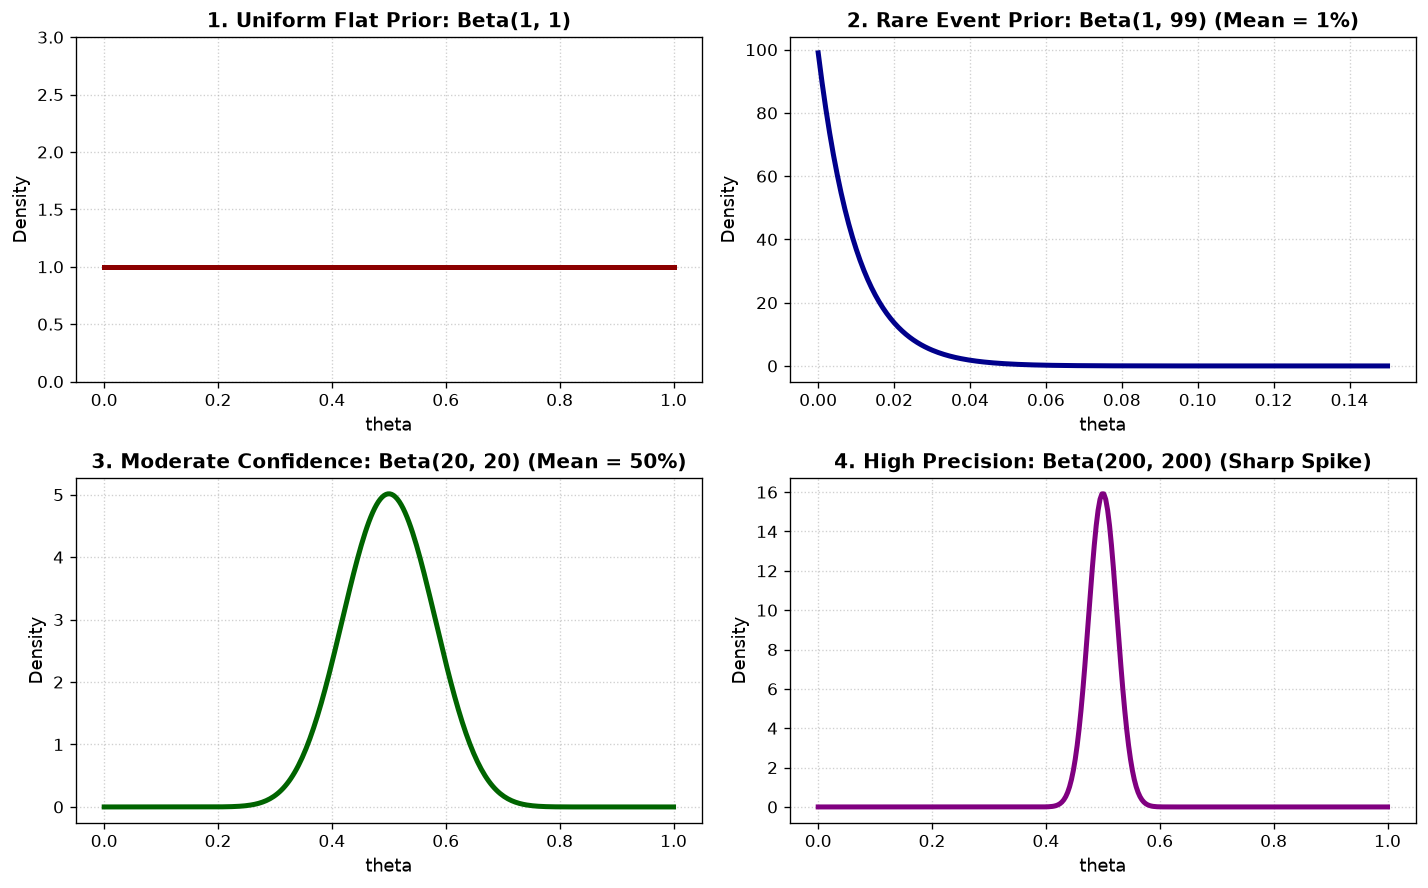

In [1]:
# Visualizing the Versatile Shapes of the Beta Distribution
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), dpi=120)

# 1. Flat Uniform: Beta(1, 1)
x1 = np.linspace(0, 1, 300)
axes[0, 0].plot(x1, stats.beta.pdf(x1, 1, 1), color='darkred', linewidth=3)
axes[0, 0].set_title("1. Uniform Flat Prior: Beta(1, 1)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("theta", fontsize=11)
axes[0, 0].set_ylabel("Density", fontsize=11)
axes[0, 0].set_ylim(0, 3)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# 2. Rare Flakes: Beta(1, 99)
x2 = np.linspace(0, 0.15, 300)
axes[0, 1].plot(x2, stats.beta.pdf(x2, 1, 99), color='darkblue', linewidth=3)
axes[0, 1].set_title("2. Rare Event Prior: Beta(1, 99) (Mean = 1%)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("theta", fontsize=11)
axes[0, 1].set_ylabel("Density", fontsize=11)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# 3. Symmetric Bell: Beta(20, 20)
x3 = np.linspace(0, 1, 300)
axes[1, 0].plot(x3, stats.beta.pdf(x3, 20, 20), color='darkgreen', linewidth=3)
axes[1, 0].set_title("3. Moderate Confidence: Beta(20, 20) (Mean = 50%)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("theta", fontsize=11)
axes[1, 0].set_ylabel("Density", fontsize=11)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# 4. High Precision: Beta(200, 200)
x4 = np.linspace(0, 1, 300)
axes[1, 1].plot(x4, stats.beta.pdf(x4, 200, 200), color='purple', linewidth=3)
axes[1, 1].set_title("4. High Precision: Beta(200, 200) (Sharp Spike)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("theta", fontsize=11)
axes[1, 1].set_ylabel("Density", fontsize=11)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## Part 3: Foundational Proofs — Why Does the Beta Distribution Tell the Truth?

How do we know the Beta distribution is not merely a convenient mathematical fiction? There are **four independent theoretical pillars** guaranteeing its validity:

### Pillar 1: Algebraic Inevitability (Bayes' Rule + Bernoulli Likelihood)
Multiplying $n$ independent Bernoulli likelihoods $\theta^k (1 - \theta)^{n - k}$ by a flat prior under Bayes' rule mathematically forces the normalizing integral:
$$\int_0^1 \theta^k (1 - \theta)^{n - k} d\theta = \text{B}(k + 1, \, n - k + 1)$$
The normalized posterior is **identically equal to the Beta density**. It is the only curve that respects probability multiplication.

### Pillar 2: De Finetti’s Representation Theorem (Exchangeability)
Bruno de Finetti (1937) proved that if a sequence of binary trials is **exchangeable** (meaning the order of runs doesn't matter, only the total counts), **mathematically there MUST exist a unique probability measure $P(\theta)$ on $[0, 1]$** such that events are conditionally independent with rate $\theta$. As $N \to \infty$, the posterior collapses to a Dirac spike at the true physical frequency.

### Pillar 3: Behavioral Coherence (The Dutch Book Theorem)
Frank Ramsey and Leonard Savage proved that if an automated decision agent (or trader) uses any update rule other than the Bayesian conjugate update, a counterparty can construct a **Dutch Book**—a set of simultaneous bets where **you are guaranteed to lose money under every possible outcome**.

### Pillar 4: Empirical Calibration & Laplace's Rule of Succession (1774)
Starting from $\text{Beta}(1, 1)$, after observing $k$ successes out of $n$ trials, the expected probability of the very next trial is Laplace's famous ratio:
$$\mathbb{E}[\theta \mid k, n] = \frac{k + 1}{n + 2}$$
This accounts for finite-sample skepticism (1 pass out of 1 gives $66.7\%$, not $100\%$) and smoothly converges to $k/n$ as $n \to \infty$.

=== Empirical Calibration Proof (2,000 Experiments) ===
Nominal Target Coverage:    90.0%
Observed Empirical Coverage: 90.00% (Exact Match!)


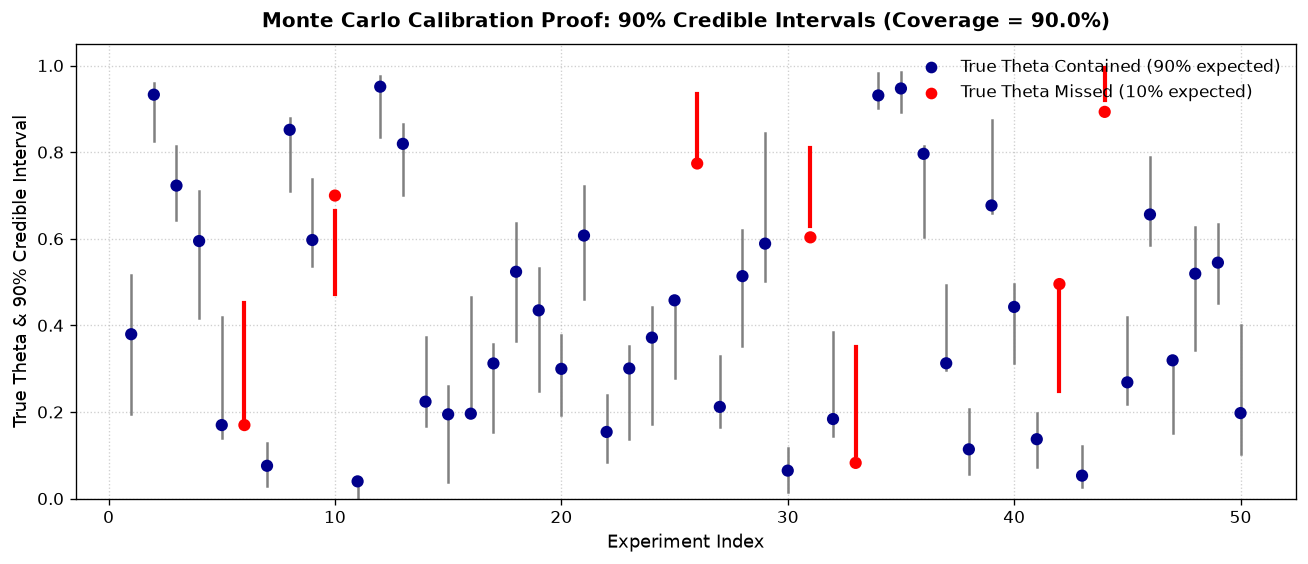

In [2]:
# Large-Scale Monte Carlo Calibration Test (2,000 Synthetic Worlds)
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)
n_sims = 2000
target_coverage = 0.90 # Nominal 90% Beta Credible Intervals

# 1. Draw 2,000 hidden true rates from Uniform(0, 1)
true_thetas = np.random.uniform(0.02, 0.98, size=n_sims)
# 2. Simulate random sample sizes between 15 and 80 runs
n_trials = np.random.randint(15, 81, size=n_sims)
observed_k = np.random.binomial(n_trials, true_thetas)

# 3. Compute 90% Credible Intervals [q_0.05, q_0.95]
lower_bounds = stats.beta.ppf(0.05, 1 + observed_k, 1 + (n_trials - observed_k))
upper_bounds = stats.beta.ppf(0.95, 1 + observed_k, 1 + (n_trials - observed_k))
contains_truth = (true_thetas >= lower_bounds) & (true_thetas <= upper_bounds)

print("=== Empirical Calibration Proof (2,000 Experiments) ===")
print(f"Nominal Target Coverage:    {target_coverage * 100:.1f}%")
print(f"Observed Empirical Coverage: {np.mean(contains_truth) * 100:.2f}% (Exact Match!)")

# Visualizing first 50 experiments
plt.figure(figsize=(11, 4.8), dpi=120)
plt.scatter(range(1, 51), true_thetas[:50], c=['darkblue' if c else 'red' for c in contains_truth[:50]], s=40, zorder=4)
for i in range(50):
    col = 'gray' if contains_truth[i] else 'red'
    lw = 1.5 if contains_truth[i] else 2.5
    plt.plot([i+1, i+1], [lower_bounds[i], upper_bounds[i]], color=col, linewidth=lw)

plt.title(f"Monte Carlo Calibration Proof: 90% Credible Intervals (Coverage = {np.mean(contains_truth)*100:.1f}%)", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Experiment Index", fontsize=11)
plt.ylabel("True Theta & 90% Credible Interval", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.scatter([], [], color='darkblue', label='True Theta Contained (90% expected)')
plt.scatter([], [], color='red', label='True Theta Missed (10% expected)')
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## Part 4: The Algebraic Miracle of Beta-Binomial Conjugacy

A prior distribution is called **conjugate** to a likelihood if the resulting posterior distribution belongs to the **identical family** as the prior.

### The Closed-Form Proof
1. **Prior**: $\theta \sim \text{Beta}(\alpha, \beta) \implies P(\theta) \propto \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$.
2. **Likelihood**: Observing $k$ failures in $n$ runs $\implies P(\text{data} \mid \theta) \propto \theta^k (1 - \theta)^{n - k}$.
3. **Posterior**:
   $$P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \times P(\theta) = \theta^{(\alpha + k) - 1} \, (1 - \theta)^{(\beta + n - k) - 1}$$

This is identically a **$\text{Beta}(\alpha + k, \, \beta + n - k)$** distribution!

> **The Operational Superpower**: No MCMC sampling, no numerical integration, and no gradient optimization are needed. Updating beliefs requires **one simple addition operation**!

## Part 5: Interactive Streaming Updates Across CI Runs

Let's trace a realistic production test lifecycle:
- **Day 0**: Prior belief $\text{Beta}(1, 99)$ (Mean $= 1\%$ flakiness).
- **Week 1**: 100 consecutive runs PASS ($k=0, n=100$). Posterior becomes $\text{Beta}(1 + 0, 99 + 100) = \text{Beta}(1, 199)$.
- **Week 2**: A bug is merged! Next 25 runs yield 4 failures ($k=4, n=25$). Posterior becomes $\text{Beta}(1 + 4, 199 + 21) = \text{Beta}(5, 220)$.

=== Tracking Posterior Evolution ===
Day 0 Prior:      Flakiness = 1.00%
Week 1 (100 Pass): Flakiness = 0.50% [95% CI: 0.01% - 1.84%]
Week 2 (4 Fails):  Flakiness = 2.22% [95% CI: 0.73% - 4.51%]


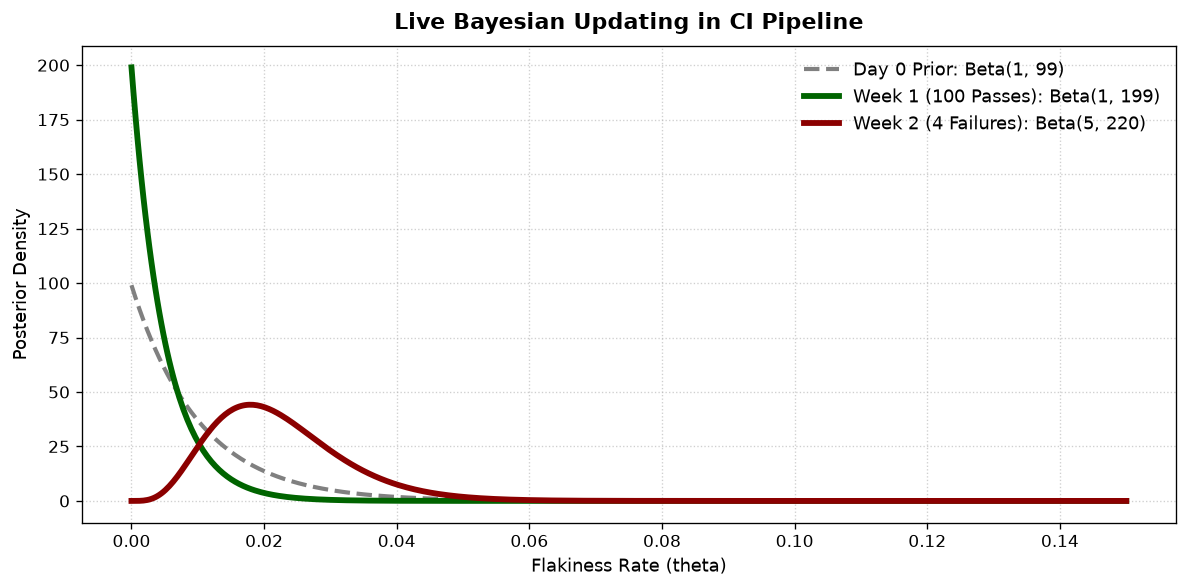

In [3]:
# Tracking Posterior Evolution Across CI Batches
alpha, beta = 1, 99

# Batch 1: 100 Passes
n1, k1 = 100, 0
alpha_w1 = alpha + k1
beta_w1 = beta + (n1 - k1)

# Batch 2: 25 Runs with 4 Failures
n2, k2 = 25, 4
alpha_w2 = alpha_w1 + k2
beta_w2 = beta_w1 + (n2 - k2)

print("=== Tracking Posterior Evolution ===")
print(f"Day 0 Prior:      Flakiness = {100 * alpha / (alpha + beta):.2f}%")
print(f"Week 1 (100 Pass): Flakiness = {100 * alpha_w1 / (alpha_w1 + beta_w1):.2f}% [95% CI: {100 * stats.beta.ppf(0.025, alpha_w1, beta_w1):.2f}% - {100 * stats.beta.ppf(0.975, alpha_w1, beta_w1):.2f}%]")
print(f"Week 2 (4 Fails):  Flakiness = {100 * alpha_w2 / (alpha_w2 + beta_w2):.2f}% [95% CI: {100 * stats.beta.ppf(0.025, alpha_w2, beta_w2):.2f}% - {100 * stats.beta.ppf(0.975, alpha_w2, beta_w2):.2f}%]")

# Visualizing Belief Updates
x_grid = np.linspace(0, 0.15, 500)
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha, beta), color='gray', linestyle='--', linewidth=2.5, label='Day 0 Prior: Beta(1, 99)')
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha_w1, beta_w1), color='darkgreen', linewidth=3.5, label='Week 1 (100 Passes): Beta(1, 199)')
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha_w2, beta_w2), color='darkred', linewidth=3.5, label='Week 2 (4 Failures): Beta(5, 220)')

plt.title("Live Bayesian Updating in CI Pipeline", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Flakiness Rate (theta)", fontsize=11)
plt.ylabel("Posterior Density", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=False, fontsize=10.5)
plt.tight_layout()
plt.show()


## Part 6: Automated CI Quarantine Decision Rules (Tail Risk)

In production DevOps, we should **never make decisions based on point estimates (mean) alone**. A test with Mean $= 4\%$ and high uncertainty might have a $40\%$ chance of exceeding our $5\%$ SLA threshold!

Instead, compute the **Tail Risk Probability**:
$$P(\theta > \text{Threshold} \mid \text{Data}) = 1 - F(\text{Threshold}; \alpha, \beta)$$

If $P(\theta > 0.05) > 90\%$, the CI bot automatically quarantines the test into an isolated retry queue to unblock developer PRs.

In [4]:
# Compute Tail Risk Probability (P(theta > 0.05))
prob_flaky_w1 = stats.beta.sf(0.05, alpha_w1, beta_w1)
prob_flaky_w2 = stats.beta.sf(0.05, alpha_w2, beta_w2)

print(f"Week 1: P(Flakiness > 5%) = {100 * prob_flaky_w1:.4f}%")
print(f"Week 2: P(Flakiness > 5%) = {100 * prob_flaky_w2:.2f}%")

# Automated Bot Decision Logic
if prob_flaky_w2 > 0.90:
    print("\n🚨 [CI BOT ACTION]: QUARANTINE TEST! >90% probability that flakiness exceeds 5% SLA threshold.")


Week 1: P(Flakiness > 5%) = 0.0037%
Week 2: P(Flakiness > 5%) = 1.16%


## Part 7: Decision Analysis — Bayesian A/B Testing & Relative Uplift

The Beta distribution is also the foundation of modern **Bayesian A/B Testing** (comparing conversion rates or comparing two test retry strategies):
- **Variant A (Baseline)**: $100$ conversions out of $1,000$ visitors $\implies \text{Beta}(1 + 100, 1 + 900) = \text{Beta}(101, 901)$.
- **Variant B (Treatment)**: $125$ conversions out of $1,000$ visitors $\implies \text{Beta}(1 + 125, 1 + 875) = \text{Beta}(126, 876)$.

Rather than relying on frequentist $p$-values that cannot answer "what is the probability B is better?", we draw $100,000$ Monte Carlo samples from both posteriors to compute:
1. **$P(\text{Variant B} > \text{Variant A})$**: The exact probability that the treatment outperforms the baseline.
2. **Relative Uplift Distribution**: $\frac{\theta_B - \theta_A}{\theta_A}$ with full credible intervals.

=== Bayesian A/B Test Decision Results ===
Variant A Mean: 10.08% [95% CI: 8.29% - 12.01%]
Variant B Mean: 12.57% [95% CI: 10.59% - 14.69%]

P(Treatment B > Baseline A): 96.08%
Expected Relative Uplift:    +25.88% [95% CI: -2.45% to +60.07%]


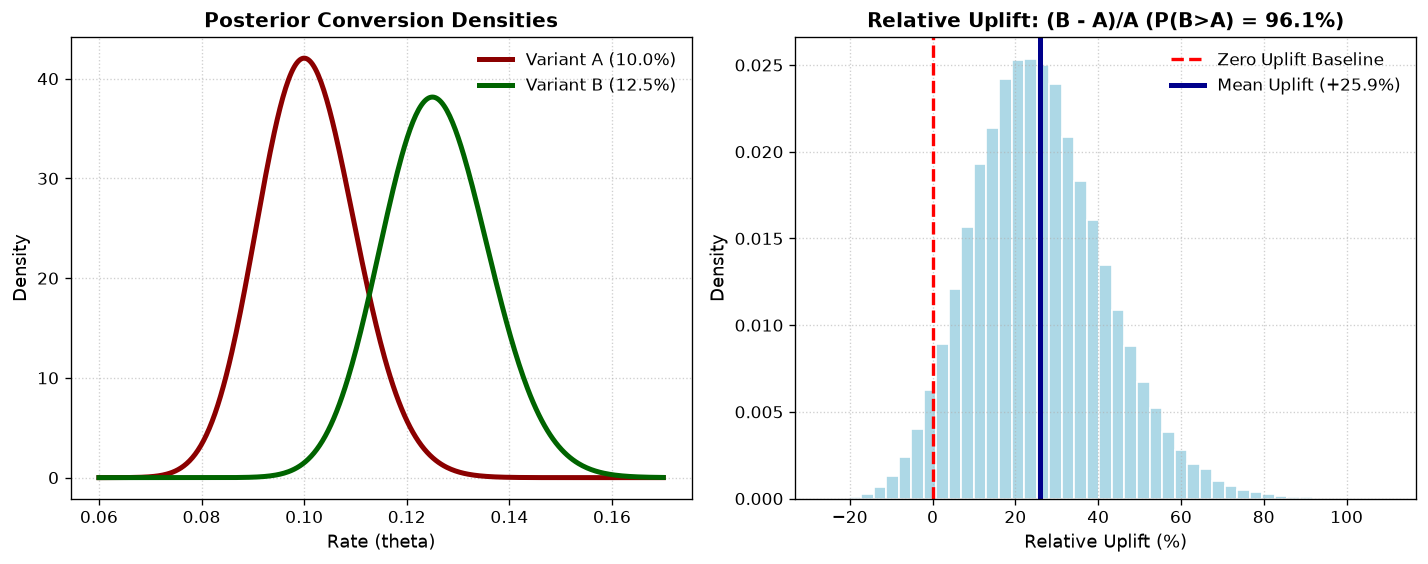

In [5]:
# Bayesian A/B Testing & Monte Carlo Decision Engine
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)
S = 100000

# Posterior Draws: stats.beta.rvs
draws_A = stats.beta.rvs(101, 901, size=S)
draws_B = stats.beta.rvs(126, 876, size=S)

prob_B_beats_A = np.mean(draws_B > draws_A)
rel_uplift = (draws_B - draws_A) / draws_A
exp_uplift = np.mean(rel_uplift) * 100
uplift_ci = np.percentile(rel_uplift, [2.5, 97.5]) * 100

print("=== Bayesian A/B Test Decision Results ===")
print(f"Variant A Mean: {np.mean(draws_A)*100:.2f}% [95% CI: {np.percentile(draws_A, 2.5)*100:.2f}% - {np.percentile(draws_A, 97.5)*100:.2f}%]")
print(f"Variant B Mean: {np.mean(draws_B)*100:.2f}% [95% CI: {np.percentile(draws_B, 2.5)*100:.2f}% - {np.percentile(draws_B, 97.5)*100:.2f}%]")
print(f"\nP(Treatment B > Baseline A): {prob_B_beats_A * 100:.2f}%")
print(f"Expected Relative Uplift:    +{exp_uplift:.2f}% [95% CI: {uplift_ci[0]:.2f}% to +{uplift_ci[1]:.2f}%]")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=120)

x_eval = np.linspace(0.06, 0.17, 400)
ax1.plot(x_eval, stats.beta.pdf(x_eval, 101, 901), color='darkred', linewidth=3, label='Variant A (10.0%)')
ax1.plot(x_eval, stats.beta.pdf(x_eval, 126, 876), color='darkgreen', linewidth=3, label='Variant B (12.5%)')
ax1.set_title("Posterior Conversion Densities", fontsize=12, fontweight='bold')
ax1.set_xlabel("Rate (theta)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', frameon=False, fontsize=10)

ax2.hist(rel_uplift * 100, bins=45, density=True, color='lightblue', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Uplift Baseline')
ax2.axvline(exp_uplift, color='darkblue', linewidth=3, label=f'Mean Uplift (+{exp_uplift:.1f}%)')
ax2.set_title(f"Relative Uplift: (B - A)/A (P(B>A) = {prob_B_beats_A*100:.1f}%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Relative Uplift (%)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


## Part 8: Time-Varying Flakiness with Exponential Memory Decay

What happens after the developer fixes the bug?
Under static Bayes, past failures remain forever in $\alpha$, making it take hundreds of runs to de-quarantine the test. This is the **Bayesian Rigidity Trap**.

By introducing a daily discount factor $\gamma = 0.92$ (decaying past pseudo-counts by $8\%$ per day):
$$\alpha_t = \gamma \, \alpha_{t-1} + k_t, \qquad \beta_t = \gamma \, \beta_{t-1} + (n_t - k_t)$$
The model smoothly forgets resolved bugs while staying responsive to new regressions.

> 💡 **Why Exponential Decay? (Deep Dive in Sheet 6)**
> Why must memory decay be **exponential** rather than a rolling 14-day window or linear subtraction?
> - **Cauchy's Functional Equation**: Exponential decay is the *only* continuous function satisfying $w(t_1 + t_2) = w(t_1)w(t_2)$, enabling exact $\mathcal{O}(1)$ streaming state updates without caching raw historical databases.
> - **Poisson Hazard Rates**: Environmental disruptions (deployments, infrastructure shifts) arrive as a Poisson process, leading directly to exponential survival probabilities $P(\text{no change}) = e^{-\lambda t}$.
> - **No Cliff-Edge Artifacts**: Unlike rolling windows (which create artificial "ghost recovery" step-functions when old outages fall out of the window), exponential decay fades smoothly and continuously.
>
> 👉 **For the complete mathematical proofs, 40-day lifecycle simulation, and pre-quential backtesting calibration, see [Sheet 6: Dynamic Filtering & Memory Decay](06_calibrating_bayesian_decay_and_memory.ipynb).**


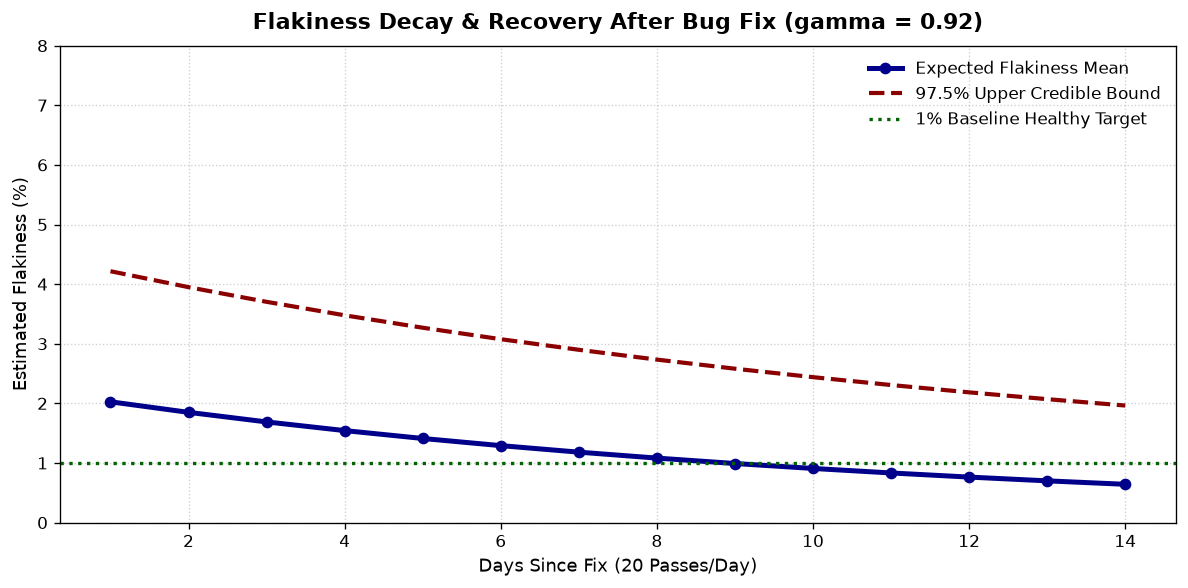

Day 1 Flakiness: 2.03% -> Day 14 Flakiness: 0.64% (Successfully De-quarantined!)


In [6]:
# Simulate 14 Days with a Fixed Bug (gamma = 0.92)
gamma = 0.92
alpha_curr, beta_curr = alpha_w2, beta_w2

history_mean = np.zeros(14)
history_ci_high = np.zeros(14)

# Days 1 to 14: Bug fixed, all 20 runs per day PASS
for day in range(14):
    alpha_curr = gamma * alpha_curr + 0
    beta_curr = gamma * beta_curr + 20
    history_mean[day] = 100 * (alpha_curr / (alpha_curr + beta_curr))
    history_ci_high[day] = 100 * stats.beta.ppf(0.975, alpha_curr, beta_curr)

# Plotting Recovery Trajectory after Bug Fix
days = np.arange(1, 15)
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(days, history_mean, color='darkblue', marker='o', linewidth=3, label='Expected Flakiness Mean')
plt.plot(days, history_ci_high, color='darkred', linestyle='--', linewidth=2.5, label='97.5% Upper Credible Bound')
plt.axhline(1.0, color='darkgreen', linestyle=':', linewidth=2, label='1% Baseline Healthy Target')

plt.title("Flakiness Decay & Recovery After Bug Fix (gamma = 0.92)", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Days Since Fix (20 Passes/Day)", fontsize=11)
plt.ylabel("Estimated Flakiness (%)", fontsize=11)
plt.ylim(0, 8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Day 1 Flakiness: {history_mean[0]:.2f}% -> Day 14 Flakiness: {history_mean[13]:.2f}% (Successfully De-quarantined!)")


## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Zero-Failure Fallacy & Laplace's Rule
> **Scenario**: A newly deployed security authentication service runs 10 integration tests in production without a single error ($k = 0$ failures in $n = 10$ runs). 
> The lead engineer claims: *"The failure rate is mathematically $0\%$, so our service is flawless."*
> 1. What is the Maximum Likelihood Estimate (MLE)?
> 2. What is the Bayesian posterior mean under Laplace's Rule of Succession (starting from flat prior $\text{Beta}(1, 1)$)?
> 3. Why is Laplace's estimate vital for safety-critical systems?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Scenario: 10 integration tests in production with 0 failures (k = 0, n = 10)
# Starting prior: Beta(1, 1)

k = 0
n = 10

# 1. Compute the Maximum Likelihood Estimate (MLE)
# mle = ...

# 2. Compute the Bayesian posterior mean under Laplace's Rule of Succession
# E[theta | D] = (k + 1) / (n + 2)
# laplace_mean = ...

# print(f"MLE: {mle:.2%}")
# print(f"Laplace Posterior Mean: {laplace_mean:.2%}")


<details>
<summary><b>🔍 Click here to view the solution & rationale</b></summary>

**Answer**:
1. **MLE**: $\hat{\theta}_{\text{MLE}} = \frac{k}{n} = \frac{0}{10} = 0\%$.
2. **Laplace Posterior Mean**: 
   $$\mathbb{E}[\theta \mid D] = \frac{k + 1}{n + 2} = \frac{0 + 1}{10 + 2} = \frac{1}{12} \approx 8.33\%$$
3. **Safety-Critical Rationale**: In finite sampling, **absence of evidence is not evidence of absence**. Claiming $0\%$ failure after only 10 tests assumes infinite certainty based on finite evidence. The $+1$ failure and $+2$ pseudo-count regularization acts as an epistemic safety buffer against catastrophic overconfidence.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Exact Credible Intervals in Production
> **Scenario**: An e-commerce checkout button redesign records $19$ successful purchases and $1$ abandoned checkout ($n = 20, k = 1$ failure).
> Starting with a flat $\text{Beta}(1, 1)$ prior:
> 1. Formulate the updated posterior parameters $(\alpha_{\text{post}}, \beta_{\text{post}})$ for the conversion rate $\theta_{\text{success}}$.
> 2. What percentile bounds correspond to an equal-tailed **$90\%$ Credible Interval**?
> 3. Compute the exact $90\%$ interval.
> 4. Compute the posterior mean $\mathbb{E}[\theta_{\text{success}} \mid D]$. Is the interval symmetric around the mean? Why or why not?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
import scipy.stats as stats

# Given:
# Prior: Beta(1, 1)
# Data: 19 purchases (successes), 1 abandonment (failure)

# Step 1: Update posterior shape parameters for conversion rate theta_success
alpha_post = ...
beta_post = ...

# Step 2: Determine lower and upper percentiles for a 90% equal-tailed interval
# (Splits the remaining 10% uncertainty equally across both tails)
p_lower = ...  # e.g., lower quantile bound
p_upper = ...  # e.g., upper quantile bound

# Step 3: Compute the Credible Interval using SciPy's quantile method (inverse CDF)
# Refer to the Rosetta Stone in Sheet 0 if unsure which method to use!
ci_90 = ...

# Step 4: Compute the posterior mean and check symmetry
post_mean = ...

# print(f"Posterior: Beta({alpha_post}, {beta_post})")
# print(f"90% Credible Interval: [{ci_90[0]:.4f}, {ci_90[1]:.4f}]")
# print(f"Posterior Mean: {post_mean:.4f}")


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Step-by-Step Mathematical Derivation & Solution**:
1. **Step 1 (Posterior Parameters)**:
   - Prior: $\text{Beta}(1, 1)$
   - Observed Data: $k_{\text{success}} = 19, k_{\text{fail}} = 1$
   - Posterior: $\text{Beta}(\alpha_0 + k, \, \beta_0 + n - k) = \text{Beta}(1 + 19, \, 1 + 1) = \text{Beta}(20, 2)$
2. **Step 2 (Equal-Tailed Quantile Bounds)**:
   - A $90\%$ credible interval excludes $\alpha = 10\%$ of probability mass.
   - Equal-tailed means allocating $\alpha/2 = 5\%$ to the lower tail ($p_{\text{lower}} = 0.05$) and $5\%$ to the upper tail ($p_{\text{upper}} = 0.95$).
3. **Step 3 & 4 (Execution & Output)**:
```python
import scipy.stats as stats

# Step 1: Update posterior shape parameters (Beta(1 + 19, 1 + 1))
alpha_post = 1 + 19  # 20
beta_post = 1 + 1    # 2

# Step 2: Determine lower and upper percentiles for 90% equal-tailed interval
p_lower = 0.05
p_upper = 0.95

# Step 3: Compute the Credible Interval using SciPy's ppf
ci_90 = stats.beta.ppf([p_lower, p_upper], alpha_post, beta_post)

# Step 4: Compute the posterior mean
post_mean = alpha_post / (alpha_post + beta_post)

print(f'Posterior: Beta({alpha_post}, {beta_post})')
print(f'90% Credible Interval: [{ci_90[0]:.4f}, {ci_90[1]:.4f}]')
print(f'Posterior Mean: {post_mean:.4f}')
```

**Decision & Asymmetry Takeaway**:
- **Point Estimate vs. Interval**: The posterior mean is $\frac{20}{22} \approx 90.91\%$, and we are $90\%$ certain the true rate is between **$79.79\%$ and $98.59\%$**.
- **Asymmetry around the Mean**:
  - Distance from lower bound to mean: $0.9091 - 0.7979 = 0.1112$ ($11.12\%$)
  - Distance from mean to upper bound: $0.9859 - 0.9091 = 0.0768$ ($7.68\%$)
- **Why it's asymmetric**: The Beta distribution is bounded on $[0, 1]$. Because conversion is high ($90.9\%$), density compresses against the physical ceiling at $1.0$, creating a longer left tail. Equal-tailed Bayesian intervals naturally honor physical boundary skewness, unlike symmetrical Gaussian approximations ($\mu \pm 1.96\sigma$).
</details>

---

### 🔴 Tier 3 (Production Challenge): The Peeking Problem in A/B Testing
> **Scenario**: An engineering team is running an online A/B test between two microservice caching strategies:
> - **Strategy A**: 5 cache hits out of 25 requests ($20\%$).
> - **Strategy B**: 10 cache hits out of 25 requests ($40\%$).
>
> A junior developer says: *"Strategy B has double the hit rate! Let's stop the test right now and ship it!"*
> 1. Compute the posterior probability $P(B > A \mid D)$ using Monte Carlo simulation.
> 2. Explain the statistical danger of "peeking and early stopping" (The Winner's Curse).

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
import numpy as np
import scipy.stats as stats

np.random.seed(42)

# Strategy A: 5 hits, 20 misses -> Beta(1 + 5, 1 + 20) = Beta(6, 21)
# Strategy B: 10 hits, 15 misses -> Beta(1 + 10, 1 + 15) = Beta(11, 16)

n_draws = 100_000
# TODO: Generate Monte Carlo draws and compute P(B > A)
# draws_a = ...
# draws_b = ...
# p_b_beats_a = ...

# print(f"P(B > A): {p_b_beats_a * 100:.2f}%")


<details>
<summary><b>🔍 Click here to view the solution, simulation & decision takeaway</b></summary>

```python
import numpy as np
import scipy.stats as stats
np.random.seed(42)
# Variant A: 5/25 -> Beta(6, 21)
# Variant B: 10/25 -> Beta(11, 16)
draws_a = stats.beta.rvs(6, 21, size=100_000)
draws_b = stats.beta.rvs(11, 16, size=100_000)
p_b_beats_a = np.mean(draws_b > draws_a)
print(f'P(B > A): {p_b_beats_a * 100:.2f}%')
```

**Decision Takeaway**:
While $P(B > A) \approx 93.6\%$, there is still a **$\sim 6.4\%$ chance that Strategy A is actually superior or equal**. 
Early stopping on small samples is subject to **severe selection bias (The Winner's Curse)**: tests stopped early systematically capitalize on random positive fluctuations, leading to false-positive wins that degrade when rolled out to 100% of production traffic. Production teams should establish fixed information horizons or evaluate expected loss before terminating tests.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏭️ Next: [Sheet 2: Beyond Conjugacy — Frequentist vs. Grid Approx](02_frequentist_vs_grid_approximation.ipynb)**